In [1]:
import copy
import collections
import random
from typing import Tuple

from tqdm import tqdm
import gymnasium as gym
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt


In [2]:
class Expert_PPO_Actor(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(Expert_PPO_Actor, self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
                    
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
                
        return x
    
    def get_action(self, obs:np.ndarray) -> int:
        obs = torch.tensor(obs, dtype = torch.float32)
        dist = self(obs) # NN_outputs -softmax-> Action distribution
        dist = F.softmax(dist, dim = 0) 
        action_probs = torch.distributions.Categorical(dist)
        picked_action = action_probs.sample()
                       
        return picked_action.item()

In [3]:
class BC_Agent():
    """Behavioral Cloning Agent"""
    def __init__(self,
        input_dim:int,
        output_dim:int,
        policy_network:torch.nn.Module,
        optimizer:torch.optim.Optimizer,
        device:torch.device = torch.device("cpu")
    ) -> None: 
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.policy_network = policy_network
        self.optimizer = optimizer
        self.device = device
        
    def predict(self, obs:np.ndarray)->torch.Tensor:
        obs = torch.tensor(obs, dtype = torch.float32).to(self.device)
        dist = self.policy_network(obs)
        # action_probs = torch.distributions.Categorical(dist)
        # picked_action = action_probs.sample()
        picked_action = torch.argmax(dist)

        return picked_action
    
    def learn(self, 
        obs:torch.Tensor, 
        action:torch.Tensor
    ) -> None:
        log_prob = torch.log(self.policy_network(obs).gather(1, action.unsqueeze(-1)))
        loss = torch.mean(-log_prob)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        
class Policy_Network(torch.nn.Module):
    def __init__(
        self,
        input_dim:int, 
        output_dim:int,
        hidden_size:int=64
    ) -> None:
        super(Policy_Network, self).__init__()
        self.fc1 = torch.nn.Linear(input_dim, hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size, output_dim)
        
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        return torch.softmax(self.fc2(x), dim=-1)

In [4]:
class ReplayBuffer():
    """Expert experience collector"""
    def __init__(
        self, 
        capacity:int, 
        device:torch.device = torch.device("cpu")
    ) -> None:
        self.device = device
        self.buffer = collections.deque(maxlen=capacity)
        
    def append(self,exp_data:tuple) -> None:
        self.buffer.append(exp_data)
        
    def sample(self,batch_size:int,shuffle:bool = True) -> Tuple[torch.Tensor,torch.Tensor]:
        if shuffle:
            self.buffer = random.sample(self.buffer,len(self.buffer))
        batch_size = min(batch_size, len(self.buffer)) # in case the buffer is not enough        
        mini_batch = random.sample(self.buffer,batch_size)
        obs_batch, action_batch = zip(*mini_batch)
        obs_batch = torch.tensor(np.array(obs_batch),dtype=torch.float32,device=self.device)
        action_batch = torch.tensor(np.array(action_batch),dtype=torch.int64,device=self.device) 
          
        return obs_batch, action_batch
    
    def fetch_all(self,shuffle:bool = True) -> Tuple[torch.Tensor,torch.Tensor]:
        if shuffle:
            self.buffer = random.sample(self.buffer,len(self.buffer))
        obs_batch, action_batch = zip(*self.buffer)
        obs_batch = torch.tensor(np.array(obs_batch),dtype=torch.float32,device=self.device)
        action_batch = torch.tensor(np.array(action_batch),dtype=torch.int64,device=self.device) 
          
        return obs_batch, action_batch
    
    def release(self) -> None:
        self.buffer.clear()
        
    def __len__(self) -> int:
        return len(self.buffer)

In [5]:
class TrainManager():
    def __init__(
        self,
        env:gym.Env,
        exp_actor_path:str = '../Models/CartPole1000_PPO_Actor.pth',
        bc_lr:float = 1e-3,
        bc_train_iters:int = 5,
        buffer_capacity:int = 1000000,
        bc_batch_size:int = 64,
        bc_train_epoch_num:int = 1000,
        eval_iters:int = 10,
        device:torch.device = torch.device("cpu"),
        seed:int = 0
    ) -> None:
        # Envs
        self.train_env = env
        self.eval_env = copy.deepcopy(env)
        obs_dim = gym.spaces.utils.flatdim(env.observation_space) 
        action_dim = env.action_space.n
        self.device = device
        # Seeds
        _ = self.train_env.reset(seed=seed) # Seed for training
        _ = self.eval_env.reset(seed=seed+1) # Seed for testing
        random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)
        torch.backends.cudnn.deterministic = True
        # Expert PPO
        self.exp_actor = Expert_PPO_Actor(obs_dim, action_dim)
        self.exp_actor.load_state_dict(torch.load(exp_actor_path))
        self.buffer = ReplayBuffer(capacity=buffer_capacity)
        # BC
        self.bc_train_epoch_num = bc_train_epoch_num
        self.bc_train_iters = bc_train_iters                                    
        self.bc_batch_size = bc_batch_size
        policy_network = Policy_Network(obs_dim, action_dim).to(self.device)
        bc_optimizer = torch.optim.Adam(policy_network.parameters(), lr=bc_lr)
        self.bc_agent = BC_Agent(
            input_dim = obs_dim, output_dim = action_dim,
            policy_network = policy_network, optimizer = bc_optimizer
        )
        
        self.eval_iters = eval_iters
        self.eval_rewards = [] 
         
        pass
        
    def sample_expert_data(self, n_episode:int, n_samples:int) -> None:
        '''
        Generate expert data by executing the 'Expert Policy' (trained PPO actor) in the environment.
        The expert data is stored in the BUFFER.
        
        Args:
            n_episode: Run the expert policy for n_episode times for generating data
            n_samples: Number of samples need to be collected
        '''
        for _ in range(n_episode):
            state,_ = self.train_env.reset()
            done = False
            while not done:
                action = self.exp_actor.get_action(state)
                next_state, _, terminated, truncated, _ = self.train_env.step(action)
                done = terminated or truncated
                self.buffer.append((state, action))
                state = next_state
        
        self.exp_obs, self.exp_action = self.buffer.sample(n_samples)
    
    def train_bc(self) -> None:
        # Train the BC agent for 'bc_train_episode_num' epochs
        with tqdm(total=self.bc_train_epoch_num, desc='BC_Training') as pbar:
            for _ in range(self.bc_train_epoch_num):
                self.train_bc_episode()
                avg_reward = self.eval()
                pbar.set_postfix({"Avg. Return": (avg_reward)})
                pbar.update(1)
    
    def train_bc_episode(self) -> None:
        # Sample a batch (of size = 'size') of expert data (idx from 0 to 'high'), allowing for replacement
        # Optimize for 'bc_train_iters' iterations
        for _ in range(self.bc_train_iters):
            sample_indices = np.random.randint(low=0,
                                            high=self.exp_obs.shape[0],
                                            size=self.bc_batch_size)
            self.bc_agent.learn(self.exp_obs[sample_indices], self.exp_action[sample_indices])
            
    def eval(self) -> float:
        temp_test_rewards = []
        for _ in range(self.eval_iters):
            obs,_ = self.eval_env.reset()
            episode_reward = 0
            done = False
            while not done:
                action = int(self.bc_agent.predict(obs).item())
                next_obs, reward, terminated, truncated, _ = self.eval_env.step(action)
                done = terminated or truncated
                episode_reward += reward
                obs = next_obs
                pass
            temp_test_rewards.append(episode_reward)
            pass
        self.eval_rewards.append(temp_test_rewards)
        
        return np.mean(temp_test_rewards)   

In [6]:
env = gym.make('CartPole-v0')

"""Using 5 samples"""
Manager = TrainManager(
        env =  env,
        exp_actor_path='../Models/CartPole1000_PPO_Actor.pth',
        bc_lr = 1e-3,
        bc_train_iters = 5,
        bc_batch_size = 32,
        bc_train_epoch_num = 500,
        buffer_capacity = 1000000,
        eval_iters = 10,
        device = torch.device("cpu"),
        seed = 0
)
Manager.sample_expert_data(n_episode=3,n_samples=5) # generate 5 samples
Manager.train_bc() # train BC using data in buffer
rewards_5 = Manager.eval_rewards

/home/zhura/miniconda3/envs/torch/lib/python3.8/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
BC_Training: 100%|██████████| 500/500 [00:34<00:00, 14.57it/s, Avg. Return=51.2]


In [7]:
env = gym.make('CartPole-v0')

"""Using 15 samples"""
Manager = TrainManager(
        env =  env,
        exp_actor_path='../Models/CartPole1000_PPO_Actor.pth',
        bc_lr = 1e-3,
        bc_train_iters = 5,
        bc_batch_size = 32,
        bc_train_epoch_num = 500,
        buffer_capacity = 1000000,
        eval_iters = 10,
        device = torch.device("cpu"),
        seed = 0
)
Manager.sample_expert_data(n_episode=3,n_samples=15)
Manager.train_bc() # train BC using data in buffer
rewards_15 = Manager.eval_rewards

/home/zhura/miniconda3/envs/torch/lib/python3.8/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
BC_Training: 100%|██████████| 500/500 [01:23<00:00,  5.96it/s, Avg. Return=136] 


In [8]:
env = gym.make('CartPole-v0')

"""Using 30 samples"""
Manager = TrainManager(
        env =  env,
        exp_actor_path='../Models/CartPole1000_PPO_Actor.pth',
        bc_lr = 1e-3,
        bc_train_iters = 5,
        bc_batch_size = 32,
        bc_train_epoch_num = 500,
        buffer_capacity = 1000000,
        eval_iters = 10,
        device = torch.device("cpu"),
        seed = 0
)
Manager.sample_expert_data(n_episode=3,n_samples=30)
Manager.train_bc() # train BC using data in buffer
rewards_30 = Manager.eval_rewards

BC_Training: 100%|██████████| 500/500 [01:31<00:00,  5.45it/s, Avg. Return=176]


In [9]:
env = gym.make('CartPole-v0')

"""Using 50 samples"""
Manager = TrainManager(
        env =  env,
        exp_actor_path='../Models/CartPole1000_PPO_Actor.pth',
        bc_lr = 1e-3,
        bc_train_iters = 5,
        bc_batch_size = 32,
        bc_train_epoch_num = 500,
        buffer_capacity = 1000000,
        eval_iters = 10,
        device = torch.device("cpu"),
        seed = 0
)
Manager.sample_expert_data(n_episode=3,n_samples=50)
Manager.train_bc() # train BC using data in buffer
rewards_50 = Manager.eval_rewards

BC_Training: 100%|██████████| 500/500 [01:27<00:00,  5.69it/s, Avg. Return=105] 


In [10]:
env = gym.make('CartPole-v0')

"""Using 80 samples"""
Manager = TrainManager(
        env =  env,
        exp_actor_path='../Models/CartPole1000_PPO_Actor.pth',
        bc_lr = 1e-3,
        bc_train_iters = 5,
        bc_batch_size = 32,
        bc_train_epoch_num = 500,
        buffer_capacity = 1000000,
        eval_iters = 10,
        device = torch.device("cpu"),
        seed = 0
)
Manager.sample_expert_data(n_episode=3,n_samples=80)
Manager.train_bc() # train BC using data in buffer
rewards_80 = Manager.eval_rewards

BC_Training: 100%|██████████| 500/500 [01:37<00:00,  5.14it/s, Avg. Return=200]


Text(0, 0.5, 'Average Return')

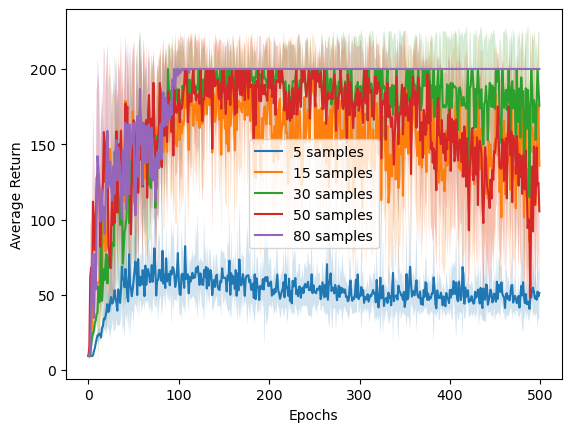

In [11]:
plt.figure()
rewards_5_mean = np.mean(rewards_5,axis=-1)
rewards_5_std = np.std(rewards_5,axis=-1)
rewards_15_mean = np.mean(rewards_15,axis=-1)
rewards_15_std = np.std(rewards_15,axis=-1)
rewards_30_mean = np.mean(rewards_30,axis=-1)
rewards_30_std = np.std(rewards_30,axis=-1)
rewards_50_mean = np.mean(rewards_50,axis=-1)
rewards_50_std = np.std(rewards_50,axis=-1)
rewards_80_mean = np.mean(rewards_80,axis=-1)
rewards_80_std = np.std(rewards_80,axis=-1)

plt.plot(rewards_5_mean,label='5 samples')
plt.fill_between(np.arange(len(rewards_5_mean)),rewards_5_mean-rewards_5_std,rewards_5_mean+rewards_5_std,alpha=0.2)
plt.plot(rewards_15_mean,label='15 samples')
plt.fill_between(np.arange(len(rewards_15_mean)),rewards_15_mean-rewards_15_std,rewards_15_mean+rewards_15_std,alpha=0.2)
plt.plot(rewards_30_mean,label='30 samples')
plt.fill_between(np.arange(len(rewards_30_mean)),rewards_30_mean-rewards_30_std,rewards_30_mean+rewards_30_std,alpha=0.2)
plt.plot(rewards_50_mean,label='50 samples')
plt.fill_between(np.arange(len(rewards_50_mean)),rewards_50_mean-rewards_50_std,rewards_50_mean+rewards_50_std,alpha=0.2)
plt.plot(rewards_80_mean,label='80 samples')
plt.fill_between(np.arange(len(rewards_80_mean)),rewards_80_mean-rewards_80_std,rewards_80_mean+rewards_80_std,alpha=0.2)
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Average Return')